© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [30]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [31]:
!git clone https://github.com/paolito81/MaskArchitectureAnomaly_CourseProject.git

Cloning into 'MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 160, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 160 (delta 29), reused 42 (delta 20), pack-reused 56 (from 2)
Receiving objects: 100% (160/160), 28.83 MiB | 21.95 MiB/s, done.
Resolving deltas: 100% (32/32), done.


In [32]:
%cd /content/MaskArchitectureAnomaly_CourseProject/eomt/
%pip install -r requirements.txt

/content/MaskArchitectureAnomaly_CourseProject/eomt


In [33]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0  # TODO: change to the GPU you want to use
img_idx = 0  # TODO: change to the index of the image you want to visualize
config_path = "/content/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"  # TODO: change to the config file
data_path = "/content/drive/MyDrive/dataset_city_scapes/coco"

# config_path = "/content/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"  # TODO: change to the config file


with open(config_path, "r") as f:
    config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [34]:
data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

Exception ignored in: <function Dataset.__del__ at 0x7e253fec42c0>
Traceback (most recent call last):
  File "/content/MaskArchitectureAnomaly_CourseProject/eomt/datasets/dataset.py", line 301, in __del__
    self.close()
  File "/content/MaskArchitectureAnomaly_CourseProject/eomt/datasets/dataset.py", line 287, in close
    item.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1988, in close
    self._fpclose(fp)
  File "/usr/lib/python3.12/zipfile/__init__.py", line 2088, in _fpclose
    fp.close()
OSError: [Errno 107] Transport endpoint is not connected
Exception ignored in: <function Dataset.__del__ at 0x7e253fec42c0>
Traceback (most recent call last):
  File "/content/MaskArchitectureAnomaly_CourseProject/eomt/datasets/dataset.py", line 301, in __del__
    self.close()
  File "/content/MaskArchitectureAnomaly_CourseProject/eomt/datasets/dataset.py", line 287, in close
    item.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1988, in close
    self._fpc

## Load model

In [35]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=data.img_size,
        num_classes=data.num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [36]:
local_ckpt_path = "/content/drive/MyDrive/CourseProjectAnomaly/eomt_coco.bin"

is_dinov3 = False  # keep False unless you know this checkpoint is a DINOv3 delta-weights checkpoint

if local_ckpt_path is None:
    warnings.warn("No local checkpoint path provided.")
else:
    if is_dinov3:
        model_kwargs["ckpt_path"] = local_ckpt_path
        model_kwargs["delta_weights"] = True

        model = (
            lit_cls(
                img_size=data.img_size,
                num_classes=data.num_classes,
                network=network,
                **model_kwargs,
            )
            .eval()
            .to(device)
        )
    else:
        state_dict = torch.load(
            local_ckpt_path,
            map_location=f"cuda:{device}" if torch.cuda.is_available() else "cpu",
            weights_only=True,
        )
        model.load_state_dict(state_dict, strict=False)

In [37]:
# name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

# if name is None:
#     warnings.warn("No logger name found in the config. Please specify a model name.")
# else:
#     try:
#         state_dict_path = hf_hub_download(
#             repo_id=f"tue-mps/{name}",
#             filename="pytorch_model.bin",
#         )

#         is_dinov3 = "dinov3" in name

#         if is_dinov3:
#             model_kwargs["ckpt_path"] = state_dict_path
#             model_kwargs["delta_weights"] = True

#         model = (
#             lit_cls(
#                 img_size=data.img_size,
#                 num_classes=data.num_classes,
#                 network=network,
#                 **model_kwargs,
#             )
#             .eval()
#             .to(device)
#         )

#         if not is_dinov3:
#             state_dict = torch.load(
#                 state_dict_path, map_location=f"cuda:{device}", weights_only=True
#             )
#             model.load_state_dict(state_dict, strict=False)

#     except RepositoryNotFoundError:
#         warnings.warn(
#             f"Pre-trained model not found for `{name}`. Please load your own checkpoint."
#         )

## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

In [38]:
COCO_ID_TO_LABEL = {
    "0": "person",
    "1": "bicycle",
    "2": "car",
    "3": "motorcycle",
    "4": "airplane",
    "5": "bus",
    "6": "train",
    "7": "truck",
    "8": "boat",
    "9": "traffic light",
    "10": "fire hydrant",
    "11": "stop sign",
    "12": "parking meter",
    "13": "bench",
    "14": "bird",
    "15": "cat",
    "16": "dog",
    "17": "horse",
    "18": "sheep",
    "19": "cow",
    "20": "elephant",
    "21": "bear",
    "22": "zebra",
    "23": "giraffe",
    "24": "backpack",
    "25": "umbrella",
    "26": "handbag",
    "27": "tie",
    "28": "suitcase",
    "29": "frisbee",
    "30": "skis",
    "31": "snowboard",
    "32": "sports ball",
    "33": "kite",
    "34": "baseball bat",
    "35": "baseball glove",
    "36": "skateboard",
    "37": "surfboard",
    "38": "tennis racket",
    "39": "bottle",
    "40": "wine glass",
    "41": "cup",
    "42": "fork",
    "43": "knife",
    "44": "spoon",
    "45": "bowl",
    "46": "banana",
    "47": "apple",
    "48": "sandwich",
    "49": "orange",
    "50": "broccoli",
    "51": "carrot",
    "52": "hot dog",
    "53": "pizza",
    "54": "donut",
    "55": "cake",
    "56": "chair",
    "57": "couch",
    "58": "potted plant",
    "59": "bed",
    "60": "dining table",
    "61": "toilet",
    "62": "tv",
    "63": "laptop",
    "64": "mouse",
    "65": "remote",
    "66": "keyboard",
    "67": "cell phone",
    "68": "microwave",
    "69": "oven",
    "70": "toaster",
    "71": "sink",
    "72": "refrigerator",
    "73": "book",
    "74": "clock",
    "75": "vase",
    "76": "scissors",
    "77": "teddy bear",
    "78": "hair drier",
    "79": "toothbrush",
    "80": "banner",
    "81": "blanket",
    "82": "bridge",
    "83": "cardboard",
    "84": "counter",
    "85": "curtain",
    "86": "door-stuff",
    "87": "floor-wood",
    "88": "flower",
    "89": "fruit",
    "90": "gravel",
    "91": "house",
    "92": "light",
    "93": "mirror-stuff",
    "94": "net",
    "95": "pillow",
    "96": "platform",
    "97": "playingfield",
    "98": "railroad",
    "99": "river",
    "100": "road",
    "101": "roof",
    "102": "sand",
    "103": "sea",
    "104": "shelf",
    "105": "snow",
    "106": "stairs",
    "107": "tent",
    "108": "towel",
    "109": "wall-brick",
    "110": "wall-stone",
    "111": "wall-tile",
    "112": "wall-wood",
    "113": "water-other",
    "114": "window-blind",
    "115": "window-other",
    "116": "tree-merged",
    "117": "fence-merged",
    "118": "ceiling-merged",
    "119": "sky-other-merged",
    "120": "cabinet-merged",
    "121": "table-merged",
    "122": "floor-other-merged",
    "123": "pavement-merged",
    "124": "mountain-merged",
    "125": "grass-merged",
    "126": "dirt-merged",
    "127": "paper-merged",
    "128": "food-other-merged",
    "129": "building-other-merged",
    "130": "rock-merged",
    "131": "wall-other-merged",
    "132": "rug-merged",
}

COCO_LABEL_TO_ID = {label: id for id, label in COCO_ID_TO_LABEL.items()}

CITYSCAPES_ID_TO_LABEL = {
    "0": "road",
    "1": "sidewalk",
    "2": "building",
    "3": "wall",
    "4": "fence",
    "5": "pole",
    "6": "traffic light",
    "7": "traffic sign",
    "8": "vegetation",
    "9": "terrain",
    "10": "sky",
    "11": "person",
    "12": "rider",
    "13": "car",
    "14": "truck",
    "15": "bus",
    "16": "train",
    "17": "motorcycle",
    "18": "bicycle",
}

CITYSCAPES_LABEL_TO_ID = {label: id for id, label in CITYSCAPES_ID_TO_LABEL.items()}


SHARED_CLASSES = [
    "person",
    "car",
    "truck",
    "bus",
    "motorcycle",
    "bicycle",
    "traffic light",
]

SHARED_LABEL_TO_ID = {label: id for id, label in enumerate(SHARED_CLASSES)}

CITYSCAPES_TO_SHARED = {
    CITYSCAPES_LABEL_TO_ID["person"]: 0,
    CITYSCAPES_LABEL_TO_ID["car"]: 1,
    CITYSCAPES_LABEL_TO_ID["truck"]: 2,
    CITYSCAPES_LABEL_TO_ID["bus"]: 3,
    CITYSCAPES_LABEL_TO_ID["motorcycle"]: 4,
    CITYSCAPES_LABEL_TO_ID["bicycle"]: 5,
    CITYSCAPES_LABEL_TO_ID["traffic light"]: 6,
}

COCO_TO_SHARED = {
    COCO_LABEL_TO_ID["person"]: 0,
    COCO_LABEL_TO_ID["car"]: 1,
    COCO_LABEL_TO_ID["truck"]: 2,
    COCO_LABEL_TO_ID["bus"]: 3,
    COCO_LABEL_TO_ID["motorcycle"]: 4,
    COCO_LABEL_TO_ID["bicycle"]: 5,
    COCO_LABEL_TO_ID["traffic light"]: 6,
}

In [ ]:
IGNORE_INDEX = 255


def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array, preds


from shared_eval.shared import remap_target_ids, remap_logits


def remap_infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array, preds = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

print(pred_array)
print(target_array)

# print(pred_array.shape)
# print(target_array.shape)

ModuleNotFoundError: No module named 'shared_eval'

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

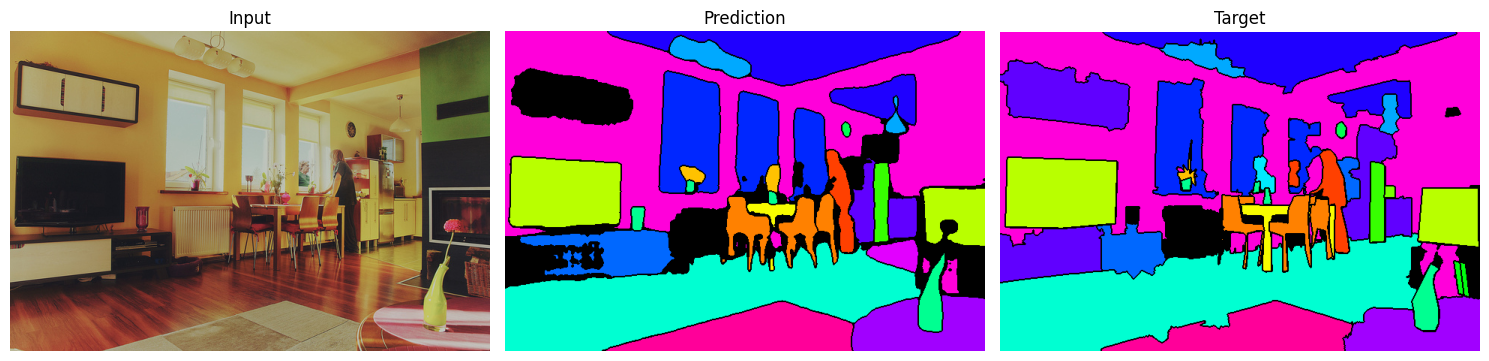

In [ ]:
def infer_panoptic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target)

In [ ]:
!python3 main.py validate \
  -c {config_path} \
  --model.network.masked_attn_enabled False \
  --trainer.devices 1 \
  --data.batch_size 4 \
  --data.path {data_path} \
  --model.ckpt_path {local_ckpt_path}

Seed set to 0
INFO:root:Loaded 197 keys
Using 16bit Automatic Mixed Precision (AMP)
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
wandb: Currently logged in as: paolito (paolito-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.19.10
wandb: Run data is saved locally in ./wandb/run-20260509_100323-pzcdapd6
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run coco_panoptic_eomt_base_640
wandb: ⭐️ View project at https://wandb.ai/paolito-politecnico-di-torino/eomt
wandb: 🚀 View run at https://wandb.ai/paolito-politecnico-di-torino/eomt/runs/pzcdapd6
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: Use